# Нейронные сети и компьютерное зрение

# Модуль 2. Элементарные нейронные сети (MLP и LeNet)

## Многослойный персептрон (MLP)

Нейронная сеть архитектуры "многослойный персептрон" (MLP) в PyTorch:

 - распознавание рукописных цифр: классический "табличный" подход;
 - создание MLP-сети и обучение на табличных данных, визуализация процесса, метрики;
 - генератор пакетов данных (мини-батчей) в PyTorch;
 - выбор параметров нейросети: 
     - функции активации,
     - скорости обучения,
     - функции-оптимизатора,
     - количество весов в слоях;
 - переобучение нейронной сети, регуляризация способом "дропаут" (dropout).


In [ ]:
!pip3 install torch torchvision

In [ ]:
!pip install torchinfo

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
import torchvision
import torchvision.transforms as transforms
from torch.utils.data.sampler import SubsetRandomSampler
import torch.nn.functional as F

from torchinfo import summary

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt
%matplotlib inline

In [ ]:
device = "cuda" if torch.cuda.is_available() else \
    "mps" if torch.backends.mps.is_built() else "cpu"
device

In [ ]:
from sklearn.datasets import load_digits

digits = load_digits()
X = digits.data
y = digits.target

print(X.shape)
print(X.max(), X.min())
print(y[:12])
print(np.unique(y))
print(np.unique(y).shape)
print(X[0].reshape(8,8))

### Решение традиционными методами

Обучим "сильную" традиционную модель, например "случайный лес", запомним максимальную точность (accuracy) модели.

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# сделаем разбиение на обучающую и валидационную выборки
X_train, X_val, y_train, y_val = train_test_split(X, y, 
                                                    test_size=0.3, 
                                                    random_state=20231110,
                                                   stratify = y)

print(X_train.shape, y_train.shape)
print(X_val.shape, y_val.shape)


In [ ]:
%%time
forest = RandomForestClassifier(n_estimators=10, max_depth=10, n_jobs=-1) 
forest.fit(X_train,y_train)

test_pred = forest.predict(X_val)
print(f"Accuracy score: {accuracy_score(y_val, test_pred)}")
print()

### Решение с помощью нейросетей

Подготовим данные: преобразуем их в тензоры, снова создадим обучающую и валидационную выборки:

In [ ]:
X_tn = torch.tensor(X * 1.0/(X.max()-X.min()), 
                    device=device, 
                    dtype=torch.float32
                   )
y_tn = torch.tensor(y, device=device)
X_tn

In [ ]:
X_train, X_val, y_train, y_val = train_test_split(X_tn, y_tn, 
                                                    test_size=0.3, 
                                                    random_state=20231110,
                                                   stratify = y)

print(X_train.shape, y_train.shape)
print(X_val.shape, y_val.shape)
print(X_train.device)

In [ ]:
# визуализируем первую дюжину цифр

pltsize=1
plt.figure(figsize=(10*pltsize, pltsize))

for i in range(12):
    plt.subplot(1,12,i+1)
    plt.axis('off')
    plt.imshow(X_train[i].reshape(8,8).cpu(), cmap="gray_r")
    plt.title(str(y_train[i].item()))

Создадим нейронную сеть с архитектурой Perceptron (MLP, multi-level perceptron):
 - три слоя: входной, скрытый и выходной
 - входной слой принимает тензор первого ранга (вектор) размером 64
 - количество весов в скрытом слое вычисляем по формуле $N_i * 2 / 3 + N_o$, получается 52*;
 - выходной слой - 10 нейронов, каждый из них предсказывает класс 0-9
 
Оптимизатор - стохастический градиентный спуск.

Функция потерь - кросс-энтропия.
<hr>
* - источник: https://www.heatonresearch.com/2017/06/01/hidden-layers.html

In [ ]:
class MLPDigits(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(8*8, 52)
        self.fc2 = nn.Linear(52, 52)
        self.fc3 = nn.Linear(52, 10)

    def forward(self, x):
        x = self.fc1(x)
        x = F.sigmoid(x)
        x = self.fc2(x)
        x = F.sigmoid(x)
        x = self.fc3(x)
        return F.log_softmax(x, dim=1)

model = MLPDigits().to(device)
optimizer = torch.optim.SGD(model.parameters(), lr=0.001, momentum=0.9)
criterion = nn.CrossEntropyLoss()

print(model)

for i, layer in enumerate(model.children()):
    print()
    print(f"Layer {i}")
    print('dims:', layer.weight.shape)
    print('weight:', layer.weight)
    print('bias:', layer.bias)

In [ ]:
# можно посмотреть summary модели в keras-стиле
summary(model, 
        input_size=X_train.shape, 
        col_names=["input_size", "output_size", "num_params"],
        device=device
       )

In [ ]:
# запустим модель
logps = model(X_train) #логарифмы вероятности отнесения к классам
# посчитаем loss
loss = criterion(logps, y_train) #кросс-энтропия
print(logps[:3])

In [ ]:
# функция для расчета точности
def accuracy_fn(logps, labels):
    pred_classes = torch.argmax(torch.exp(logps), axis=1)
    val_classes = labels
    return float(torch.eq(pred_classes, val_classes).sum() / labels.shape[0])

# функция для обучения
def train(model, epochs=10000, report_positions=20):
    
    results = {'epoch_count': [], 'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    
    # прогоняем данные по нейросети
    for epoch in range(epochs):

        # Put the model in training mode
        model.train()

        y_logps = model(X_train) #логарифмы вероятности отнесения к классам
        loss = criterion(y_logps, y_train) #кросс-энтропия

        acc = accuracy_fn(y_logps, y_train) # calculate the accuracy; convert the labels to integers

        optimizer.zero_grad() # reset the gradients so they don't accumulate each iteration
        loss.backward() # backward pass: backpropagate the prediction loss
        optimizer.step() # gradient descent: adjust the parameters by the gradients collected in the backward pass

        # Put the model in evaluation mode
        model.eval() 

        with torch.inference_mode():
            y_val_logps = model(X_val)

            valid_loss = criterion(y_val_logps, y_val)
            valid_acc = accuracy_fn(y_val_logps, y_val)    

        # Print progress a total of 20 times
        if epoch % (epochs // report_positions) == 0 or epochs<50:
            print(f'Epoch: {epoch+1:4.0f} | Train Loss: {loss:.5f}, Accuracy: {acc*100:.2f}% | \
                Validation Loss: {valid_loss:.5f}, Accuracy: {valid_acc*100:.2f}%')

        results['epoch_count'] += [epoch]
        results['train_loss'] += [loss.cpu().detach().numpy()]
        results['train_acc'] += [acc]
        results['val_loss'] += [valid_loss.cpu().detach().numpy()]
        results['val_acc'] += [valid_acc]
            
    return results
    

In [ ]:
# рисовалка графиков
def plot_results(results):
    
    fig, axs = plt.subplots(1,2)
    
    fig.set_size_inches(10,3)
    
    for i, loss_acc in enumerate(['loss', 'acc']):
        for train_val in ['train', 'val']:
            axs[i].plot(results['epoch_count'], results[f'{train_val}_{loss_acc}'], label=f'{loss_acc} {train_val}')
            
        axs[i].legend()

    plt.show()

Собственно, запуск обучения

In [ ]:
%%time
results = train(model, 10000)

plot_results(results)

In [ ]:
model.fc1.weight.grad

Поменяем скорость обучения в оптимизаторе:

In [ ]:
for lr in [0.05, 0.1, 0.2]:
    print(f"LR: {lr}")
    model = MLPDigits().to(device)
    optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9)
    results = train(model, epochs=1000, report_positions=10)
    plot_results(results)

In [ ]:
%%time
model = MLPDigits().to(device)
optimizer = torch.optim.SGD(model.parameters(), lr=0.2, momentum=0.9)
results = train(model, epochs=650)
plot_results(results)

Сделаем класс для модели с возможностью вариативности по следующим параметрам:
    - кол-во нейронов в скрытом слое
    - функции активации

In [ ]:
class MLPDigits_vary(nn.Module):
    
    def __init__(self, activation='sigmoid', hidden=52, **kwargs):
        super().__init__()
        self.fc1 = nn.Linear(8*8, hidden)
        self.fc2 = nn.Linear(hidden, hidden)
        self.fc3 = nn.Linear(hidden, 10)
        self.activation = eval(f'F.{activation}')

    def forward(self, x):
        x = self.fc1(x)
        x = self.activation(x)
        x = self.fc2(x)
        x = self.activation(x)
        x = self.fc3(x)
        return F.log_softmax(x, dim=1)

In [ ]:
vary = 'activation' #здесь пишем, что варьируем
var_values = ['relu', 'tanh', 'sigmoid'] # здесь перечисляем варианты


dict_vary = {'hidden': 52,
            'activation': 'sigmoid',
            'lr': 0.2,
            'momentum': 0.9,
            'optimizer': 'SGD',
            'epochs': 100}

dict_acc = {} # here we collect data for comparison

for var in var_values:
    print(f"{vary}: {var}")
    dict_vary[vary] = var
    model = MLPDigits_vary( **dict_vary ).to(device)
    optimizer = torch.optim.RMSprop(model.parameters(), lr=dict_vary['lr'], momentum=dict_vary['momentum']) \
            if dict_vary['optimizer']=='RMSprop' else \
                torch.optim.Adam(model.parameters(), lr=dict_vary['lr']) \
            if dict_vary['optimizer']=='Adam' else \
                    torch.optim.SGD(model.parameters(), lr=dict_vary['lr'], momentum=dict_vary['momentum'])
    results = train(model, epochs=dict_vary['epochs'], report_positions=10)
    dict_acc[f'err_{var}'] = results['val_loss']
    dict_acc[f'acc_{var}'] = results['val_acc']
    dict_acc[f'epochs_{var}'] = results['epoch_count']
    
    plot_results(results)

    
fig_var, axs_var = plt.subplots(1,2)
fig_var.set_size_inches(10,3)
for var in var_values:
    axs_var[0].plot(dict_acc[f'epochs_{var}'], dict_acc[f'err_{var}'], label=f'loss on {vary}={var}')
    axs_var[0].legend()
    axs_var[1].plot(dict_acc[f'epochs_{var}'], dict_acc[f'acc_{var}'], label=f'acc on {vary}={var}')
    axs_var[1].legend()
    
    
plt.show()

#### Практика

Используя код выше, поэкспериментируйте с моделью:
 - попробуйте изменить количество весов в скрытом и выходном слоях (попробуйте 50, 32, 16, 8, 2, 1);
 - попробуйте различную скорость обучения;
 - попробуйте различные функции активации;
 - поэкпериметируйте с количеством эпох.
 
Постарайтесь выйти на оптимальный уровень точности и скорости обучения.
 
Сообщите максимальное значение точности на валидационном подмножестве данного датасета, конфигурацию модели и параметры обучения.


In [ ]:
%%time
dict_vary = ? # ваши параметры настройки модели

model = MLPDigits_vary( **dict_vary ).to(device)
optimizer = torch.optim.RMSprop(model.parameters(), lr=dict_vary['lr'], momentum=dict_vary['momentum']) \
        if dict_vary['optimizer']=='RMSprop' else \
            torch.optim.Adam(model.parameters(), lr=dict_vary['lr']) \
        if dict_vary['optimizer']=='Adam' else \
                torch.optim.SGD(model.parameters(), lr=dict_vary['lr'], momentum=dict_vary['momentum'])
results = train(model, epochs=dict_vary['epochs'], report_positions=10)


In [ ]:
plot_results(results)

summary(model, 
        input_size=X_train.shape, 
        col_names=["input_size", "output_size", "num_params"],
        device=device
       )

### Загрузка данных в модель в виде мини-батчей

Выше мы обучали модель на всех имеющихся данных. Но при обучении нейросетей данные чаще всего загружают в виде мини-пакетов (мини-батчей). Это делается для того, чтобы:
- обучать модель на разнообразии данных: в рамках одной эпохи каждый цикл обучения она будет видеть уникальные данные;
- минимизировать объем памяти, используемой при обучении;
- ускорить работу оптимизатора: он будет гораздо быстрее обрабатывать небольшой объем данных6 нежели чем весь датасет.

Для этого можно использовать встроенный в PyTorch механизм генерации мини-батчей. На базе стандартного генератора PyTorch можно создать свой собственный, который будет отправлять в модель именно ваши данные в нужном именно вам виде.

Для начала нужно создать свой класс на базе класса PyTorch ```Dataset```:

```python
class Dataset(object):
    """An abstract class representing a Dataset.
    All other datasets should subclass it. All subclasses should override
    ``__len__``, that provides the size of the dataset, and ``__getitem__``,
    supporting integer indexing in range from 0 to len(self) exclusive.
    """

    def __getitem__(self, index):
        raise NotImplementedError

    def __len__(self):
        raise NotImplementedError

    def __add__(self, other):
        return ConcatDataset([self, other])
````

Затем на базе этого класса будут созданы объекты-генераторы данных, уже на этапе создания в них будет передана функция ```transforms.ToTensor()``` для преобразования изображений "на лету", по требованию.

In [ ]:
# класс генератора:
class DatasetDigits(Dataset):
    
    def __init__(self, X, y=None, transform=None):
        self.X = X
        self.y = y
        self.transform = transform
        
    def __len__(self):
        return self.X.shape[0]
    
    def __getitem__(self, index):
        # сразу представляем цифру как ndarray размерностью (Height * Width * Channels)
        # конвертируем цифры в np.uint8 [Unsigned integer (0 to 255)] - стандарт для изображений
        # чтобы отрабатывала стандартная функция ToTensor(), мы определяем размерность тензора (H, W, C)
        image = self.X[index].astype(np.uint8).reshape((8, 8, 1))
        
        if self.transform is not None:
            image = self.transform(image)
            
        if self.y is not None:
            return (image, self.y[index])  
        else:
            return image

# снова сделаем разбиение на обучающую и валидационную выборки
# старые переменные X_train, X_val... - это нормированные тензоры, а нам нужны изображения в исходном формате
X_train, X_val, y_train, y_val = train_test_split(X, y, 
                                                    test_size=0.3, 
                                                    random_state=20231110,
                                                   stratify = y)



# создадим генераторы обучающих и тестовых данных:
train_data = DatasetDigits(X_train, y_train, transform=transforms.ToTensor())
val_data = DatasetDigits(X_val, y_val, transform=transforms.ToTensor())

In [ ]:
for i, image_label in enumerate(train_data):
    if i>=3: break
    image, label = image_label
    print(image.shape, label)
    print(image.view((8,8)))
    

Следующий шаг - создание генератора батчей:

In [ ]:
batch_size = 20

train_generator = torch.utils.data.DataLoader(train_data, batch_size=batch_size,
    sampler=SubsetRandomSampler(list(range(y_train.shape[0]))))
val_generator=  torch.utils.data.DataLoader(val_data, batch_size=batch_size,
    sampler=SubsetRandomSampler(list(range(y_val.shape[0]))))

In [ ]:
# визуализируем батч
dataiter = iter(train_generator)
images, labels = next(dataiter)
images = images.numpy()

print(images.shape)

fig = plt.figure(figsize=(20, 4))
for idx in np.arange(20):
    ax = fig.add_subplot(2, 20//2, idx+1, xticks=[], yticks=[])
    ax.imshow(np.squeeze(images[idx]), cmap='gray_r')
    # print out the correct label for each image
    # .item() gets the value contained in a Tensor
    ax.set_title(str(labels[idx].item()))

Перепишем функцию ```train()``` - помимо циклов по эпохам сделаем цикл для переборки батчей.

In [ ]:
def train_batches(model, 
                  train_generator,
                  valid_generator,
                  batch_size=20, epochs=40, report_positions=20, **kwargs):
    
    results = {'epoch_count': [], 'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    
    # прогоняем данные по нейросети
    for epoch in range(epochs):
        model.train()
        
        train_loss = valid_loss = 0.0; 
        train_correct = valid_correct = 0.0
        
        for X_batch, y_batch in train_generator:
            
            X_batch = X_batch.to(device); y_batch = y_batch.to(device)
            
            y_logps = model(X_batch) #логарифмы вероятности отнесения к классам
            loss = criterion(y_logps, y_batch) #кросс-энтропия
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            train_loss += loss.data.item()
            train_correct += accuracy_fn(y_logps, y_batch) * y_batch.shape[0]
            
        train_loss /= len(train_generator.dataset)
        train_acc = 100 * train_correct / len(train_generator.dataset)

        # Валидацию тоже делаем по батчам
        model.eval()         
        
        for valid_batches, (X_val_batch, y_val_batch) in enumerate(valid_generator):
            X_val_batch = X_val_batch.to(device); y_val_batch = y_val_batch.to(device)
            y_batch_logps = model(X_val_batch)
            loss = criterion(y_batch_logps, y_val_batch)
            
            valid_loss += loss.data.item()
            valid_correct += accuracy_fn(y_batch_logps, y_val_batch) * y_val_batch.shape[0]
            
        valid_loss /= len(valid_generator.dataset)
        valid_acc = 100 * valid_correct / len(valid_generator.dataset)
        
        results['epoch_count'] += [epoch]
        results['train_loss'] += [ train_loss ]
        results['train_acc'] += [ train_acc ]
        results['val_loss'] += [ valid_loss ]
        results['val_acc'] += [ valid_acc ]
        
        if epoch % (epochs // report_positions) == 0 or epochs<50:
            print(f"Epoch: {epoch+1:4.0f} | Train Loss: {train_loss:.5f}, "+\
                  f"Accuracy: {train_acc:.2f}% | \
                Validation Loss: {valid_loss:.5f}, Accuracy: {valid_acc:.2f}%")
            
    return results




Т.к. валидация остается без изменений, валидационный сет надо преобразовать в тензор 

In [ ]:
X_val_tn = transforms.ToTensor()(X_val.astype(np.uint8).reshape((-1,8,8)))
X_val_tn = X_val_tn.permute(1,2,0)
X_val_tn = X_val_tn.unsqueeze(dim=1)
X_val_tn = X_val_tn.to(device)
y_val_tn = torch.tensor(y_val, device=device)

print(X_val_tn.shape)
print(X_val_tn.device)

pltsize=1
plt.figure(figsize=(10*pltsize, pltsize))

for i in range(12):
    plt.subplot(1,12,i+1)
    plt.axis('off')
    plt.imshow(X_val_tn[i].reshape(8,8).cpu(), cmap="gray_r")
    plt.title(str(y_val[i].item()))

Будем обучать ту же модель, что и в прошлый раз, ```MLPDigits_vary()```, только добавим ей "выпрямляющий" код на входе, чтобы она могла работать с тензорами-изображениями PyTorch: 

In [ ]:
class MLPDigits_vary(nn.Module):
    
    def __init__(self, activation='sigmoid', hidden=52, **kwargs):
        super().__init__()
        self.fc1 = nn.Linear(8*8, hidden)
        self.fc2 = nn.Linear(hidden, hidden)
        self.fc3 = nn.Linear(hidden, 10)
        self.activation = eval(f'F.{activation}')

    def forward(self, x):
        x = x.view(-1, 8 * 8) # изображение приходит в формате (1,8,8), делаем его плоским
        x = self.fc1(x)
        x = self.activation(x)
        x = self.fc2(x)
        x = self.activation(x)
        x = self.fc3(x)
        return F.log_softmax(x, dim=1)

criterion = nn.CrossEntropyLoss()


Поэкспериментируйте с моделью, варьируйте количество эпох и размер пакета.

In [ ]:
vary = 'batch_size' #здесь пишем, что варьируем
var_values = [64, 25, 10] # здесь перечисляем варианты


dict_vary = {'hidden': 12,
            'activation': 'tanh',
            'batch_size': 20,
            'lr': 0.002,
            'momentum': 0.9,
            'optimizer': 'RMSprop',
            'epochs': 30}

dict_acc = {} # here we collect data for comparison

for var in var_values:
    print(f"{vary}: {var}")
    dict_vary[vary] = var
    model = MLPDigits_vary( **dict_vary ).to(device)
    optimizer = torch.optim.RMSprop(model.parameters(), lr=dict_vary['lr'], momentum=dict_vary['momentum']) \
            if dict_vary['optimizer']=='RMSprop' else \
                torch.optim.Adam(model.parameters(), lr=dict_vary['lr']) \
            if dict_vary['optimizer']=='Adam' else \
                    torch.optim.SGD(model.parameters(), lr=dict_vary['lr'], momentum=dict_vary['momentum'])
    
    # добавляем создание генератора для нужного нам количества батчей
    train_generator = torch.utils.data.DataLoader(train_data, 
                                                  batch_size=dict_vary['batch_size'],
        sampler=SubsetRandomSampler(list(range(y_train.shape[0]))))
    valid_generator = torch.utils.data.DataLoader(val_data, 
                                                  batch_size=dict_vary['batch_size'],
        sampler=SubsetRandomSampler(list(range(y_val.shape[0]))))
    
    results = train_batches(model, train_generator, valid_generator, report_positions=10, **dict_vary)
    dict_acc[f'err_{var}'] = results['val_loss']
    dict_acc[f'acc_{var}'] = results['val_acc']
    dict_acc[f'epochs_{var}'] = results['epoch_count']
    
    plot_results(results)

    
fig_var, axs_var = plt.subplots(1,2)
fig_var.set_size_inches(10,3)
for var in var_values:
    axs_var[0].plot(dict_acc[f'epochs_{var}'], dict_acc[f'err_{var}'], label=f'loss on {vary}={var}')
    axs_var[0].legend()
    axs_var[1].plot(dict_acc[f'epochs_{var}'], dict_acc[f'acc_{var}'], label=f'acc on {vary}={var}')
    axs_var[1].legend()
    
    
plt.show()

summary(model, 
        input_size=X_train.shape, 
        col_names=["input_size", "output_size", "num_params"],
        device=device
       )

## MNIST

Попробуем теперь обучить нашу модель на датасете MNIST, это те же "рукописные цифры", но в разрешении 28x28 и в количестве 50000.

In [ ]:
from torchvision import datasets

trainset = datasets.MNIST('./data', download=True, train=True, transform=transforms.ToTensor())
valset = datasets.MNIST('./data', download=True, train=False, transform=transforms.ToTensor())

print(len(trainset))
print(len(valset))

In [ ]:
imgs = torch.stack([img for img, _ in trainset], dim=0)

mean = imgs.view(1, -1).mean(dim=1)    # or imgs.mean()
std = imgs.view(1, -1).std(dim=1)     # or imgs.std()
mean, std

In [ ]:
mnist_transforms = transforms.Compose([transforms.ToTensor(),
                                       transforms.Normalize(mean=mean, std=std)])

trainset = datasets.MNIST('./data', download=True, train=True, transform=mnist_transforms)
valset = datasets.MNIST('./data', download=True, train=False, transform=mnist_transforms)

In [ ]:
batch_size=128

train_generator_MNIST = torch.utils.data.DataLoader(trainset, batch_size=batch_size, shuffle=True)
val_generator_MNIST = torch.utils.data.DataLoader(valset, batch_size=batch_size, shuffle=True)

In [ ]:
# визуализируем батч
dataiter = iter(train_generator_MNIST)
images, labels = next(dataiter)
images = images.numpy()

print(images.shape)

fig = plt.figure(figsize=(20, 4))
for idx in np.arange(20):
    ax = fig.add_subplot(2, 20//2, idx+1, xticks=[], yticks=[])
    ax.imshow(np.squeeze(images[idx]), cmap='gray')
    # print out the correct label for each image
    # .item() gets the value contained in a Tensor
    ax.set_title(str(labels[idx].item()))

Cоздадим модель на базе последней, повысим размерность входного слоя до 28x28:

In [ ]:
class MLP_MNIST_vary(nn.Module):
    
    def __init__(self, activation='sigmoid', hidden=52, **kwargs):
        super().__init__()
        self.fc1 = nn.Linear(28*28, hidden)
        self.fc2 = nn.Linear(hidden, hidden)
        self.fc3 = nn.Linear(hidden, 10)
        self.activation = eval(f'F.{activation}')

    def forward(self, x):
        x = x.view(-1, 28 * 28) # изображение приходит в формате (1,8,8), делаем его плоским
        x = self.fc1(x)
        x = self.activation(x)
        x = self.fc2(x)
        x = self.activation(x)
        x = self.fc3(x)
        return F.log_softmax(x, dim=1)



In [ ]:
dict_vary = {'hidden': 512,
            'activation': 'tanh',
            'batch_size': batch_size,
            'lr': 0.01,
            'momentum': 0.9,
            'optimizer': 'RMSprop',
            'epochs': 10}

model = MLP_MNIST_vary( **dict_vary ).to(device)

optimizer = torch.optim.SGD(model.parameters(), lr=dict_vary['lr'], momentum=dict_vary['momentum']) 
criterion = nn.CrossEntropyLoss()

print(model)

results = train_batches(model, 
                        train_generator_MNIST, 
                        val_generator_MNIST, report_positions=10, **dict_vary)

plot_results(results)
summary(model, 
        input_size=images.shape, 
        col_names=["input_size", "output_size", "num_params"],
        device=device
       )

## Регуляризация добавлением слоя Dropout

Добавим в модель "прореживание" - слой dropout, который в момент обучения блокирует ряд нейронов (позиций в матрицах соотв. слоев).

In [ ]:
class MLPDigits_dropout(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(8*8, 24)
        self.fc2 = nn.Linear(24, 24)
        self.fc3 = nn.Linear(24, 10)
        self.dropout = nn.Dropout(0.25)

    def forward(self, x):
        x = x.view(-1, 8 * 8) # изображение приходит в формате (1,8,8), делаем его плоским
        x = self.fc1(x)
        x = F.tanh(x)
        x = self.dropout(x)
        x = self.fc2(x)
        x = F.tanh(x)
        x = self.dropout(x)
        x = self.fc3(x)
        return F.log_softmax(x, dim=1)

model = MLPDigits_dropout().to(device)

print(model)

optimizer = torch.optim.SGD(model.parameters(), lr=0.01, momentum=0.9)
criterion = nn.CrossEntropyLoss()

results = train_batches(model, batch_size=20, epochs=800)

plot_results(results)

#### Практика

Ответьте на следующие вопросы:
1. Почему точность модели на тестовой выборке оказалась выше, чем на обучающей?
2. Найдите все изображения цифр, которые ошибочно распознаются моделью и выведите их на экран.

In [ ]:
# ваш код здесь (задание 2)


## Сверточные нейронные сети (CNN)

Convolutional Neural Networks, "Сверточные Нейросети". Применение операции "свертка" в нескольких слоях нейросети - революционное решение, которое позволило радикально повысить качество решения задач компьютерного зрения. Впервые было продемонстировано Яном Лекуном в Париже в 1993 году в задаче "распознавание рукописных цифр" (датасет MNIST).

В данном модуле рассмотрим процесс создания и обучение сверточных нейросетей в PyTorch:
- операция "свертка", определение, реализация в PyTorch;
- создание многослойной нейронной сети со сверточными слоями и распознавание рукописных цифр:
    - добавление сверточных слоев,
    - слои-объединения (max-pooling),
    - пакетная нормализация (batch normalization);
- задача бинарной классификации на примере набора полноцвентых изображений "кошки против собак", обучение нейросети с "ноля";
- дообучение готовых моделей, загруженных из интернета (на примере модели архитектуры ResNet-50).





In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
import torchvision
import torchvision.transforms as transforms

from torch.nn.functional import normalize

from torch.utils.data.sampler import SubsetRandomSampler
import torch.nn.functional as F

import numpy as np

import matplotlib.pyplot as plt
%matplotlib inline

### Операция "Свертка" (Convolution)

Выполнение операции "двумерная свертка" (convolution 2D) иллюстрирует анимированное изображение ниже. Суть операции в следующем:
- ядро свертки - квадратная матрица размером $n * n$
- по матрице размера $M * N$ , над которой выполняется операция "свертка"  запускается "окно" размером с ядро свертки ($n * n$), оно двигается слева направо, сверху вниз,с заданным шагом (stride);
- на каждом шаге происходит поэлементное умножение ядра свертки на содержимое текущего "окна", происходит суммирование произведения (операция эквивалентна скалярному произведению "плоских" представлений соотв. матриц);
- результат записывается в соответствующую ячейку результирующей матрицы.

![Convolution Gif](./conv.gif)

На данном изображении к исходной матрице применяется свертка со следующим ядром:

```
 0 1 2 
 2 2 0 
 0 1 2
```

Запустим "свертку" на изображении.

Для этого создадим сверточный слой вне сети и запустим в нем некоторую свертку поверх изображения Лены.

In [ ]:
from PIL import Image, ImageFilter  

lena = Image.open('lena.jpg')

display(lena)

t_lena = transforms.ToTensor()(lena)

print(t_lena.shape)

In [ ]:
# создаем сверточный слой вне сети
conv = nn.Conv2d(in_channels=1, # принимает одноканальное изображение размером (1, 256, 256)
                 out_channels=1, # отдает тоже одноканальное изображение размером (1, 254, 254) 
                 kernel_size=3, # ядро размера 3х3
                 padding=0, 
                 bias=False)
# обратите внимание на размер тензора весов сети
# assert conv.weight.shape == (OUT_CHANNELS, IN_CHANNELS, KERNEL_SIZE, KERNEL_SIZE)
conv.weight.shape

In [ ]:
# сделаем Лену одноканальной, чтобы передать ее в сверточный слой
t_lena_bw = (t_lena.sum(axis=0) / 3).unsqueeze(0)

display( transforms.ToPILImage()( t_lena_bw ) )

In [ ]:
# возьмем для примера "вертикальное" ядро детектора краев Собеля-Фельдмана 
kernel = torch.tensor([[-1, 0, 1], 
                       [-2, 0, 2], 
                       [-1, 0, 1]], dtype =torch.float32)




In [ ]:
# нормализуем вывод
out_img -= out_img.min()
out_img /= out_img.max()

display( transforms.ToPILImage()( out_img ) )


In [ ]:
kernel = torch.tensor([[2, 2, 2], 
                       [2, 2, 2], 
                       [2, 2, 2]], dtype =torch.float32)

# разрешаем копировать веса и копируем их
with torch.no_grad():
    conv.weight.copy_( kernel )
    
out_img = conv(t_lena_bw)

out_img -= out_img.min()
out_img /= out_img.max()

display( transforms.ToPILImage()( out_img ) )

### Практика

1. В коде вверху поэкпериментируйте с другими значениями весов ядра свертки. Поищите в интернете веса для других фильтров, попробуйте их применить на исходном изображении.

2. Реализуйте детектор краев Собеля-Фельдмана. То, что мы уже получили - это матрица градиентов по вертикальной оси. Используя вертикально "отзеркаленное" и транспонированное ядро, нужно получить матрицу градиентов по горизонтальной оси, а затем вычислить квадратный корень из их суммы: $G = \sqrt{G_x^2 + G_y^2}$. Номализуйте полученное изображение и выведите его на экран.

Суть метода Собеля-Фельдмана:
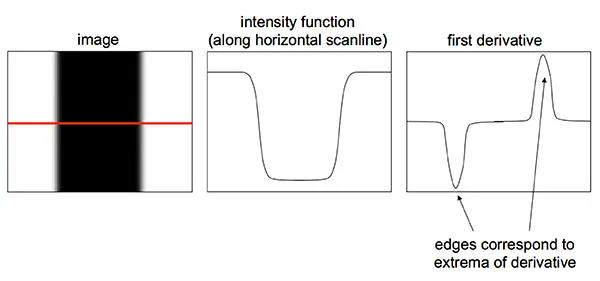

Ядра сверток:
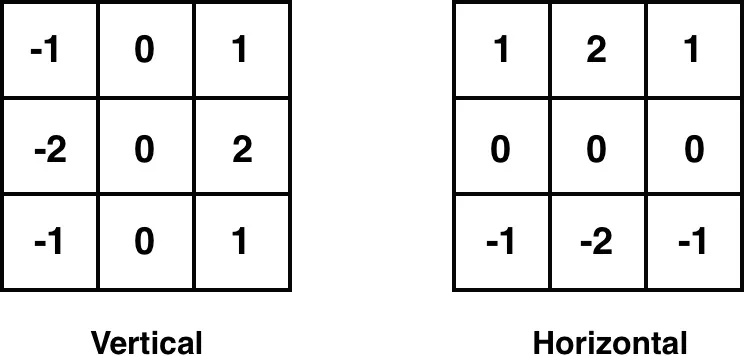

Итоговое изображение:
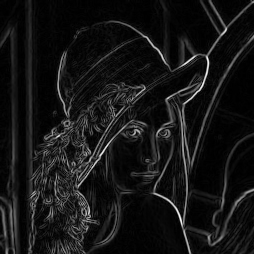

<small>Источник: 
1. https://www.adeveloperdiary.com/data-science/computer-vision/how-to-implement-sobel-edge-detection-using-python-from-scratch/
2. https://www.reg.ru/blog/svyortka-v-deep-learning-prostymi-slovami/    
    
</small>

In [ ]:
kernel_v = torch.tensor([[-1, 0, 1], 
                       [-2, 0, 2], 
                       [-1, 0, 1]], dtype =torch.float32)

kernel_h = kernel_v.flip(1).T

# ваш код здесь
with torch.no_grad():
    conv.weight.copy_( kernel_v )
grad_v = conv(t_lena_bw)

with torch.no_grad():
    conv.weight.copy_( kernel_h )
grad_h = conv(t_lena_bw)

out_img = torch.sqrt( grad_v ** 2 + grad_h ** 2 )

out_img -= out_img.min()
out_img /= out_img.max()

display( transforms.ToPILImage()( out_img ) )

### Обучение нейросети на наборе данных MINST

Это те же "рукописные цифры", только с разрешением 28x28 пикселей и в количестве 10000 экзепляров. Инструменты для работы с ним есть во всех фреймворках для работы с нейросетями. PyTorch - не исключение.

In [ ]:
from torchvision import datasets

mean, std = 0.1307, 0.3081

mnist_transforms = transforms.Compose([transforms.ToTensor(),
                                       transforms.Normalize(mean=mean, std=std)])

trainset = datasets.MNIST('./data', download=True, train=True, transform=mnist_transforms)
valset = datasets.MNIST('./data', download=True, train=False, transform=mnist_transforms)

print(len(trainset))
print(len(valset))

In [ ]:
batch_size=128

train_generator_MNIST = torch.utils.data.DataLoader(trainset, batch_size=batch_size, shuffle=True)
val_generator_MNIST = torch.utils.data.DataLoader(valset, batch_size=batch_size, shuffle=True)

## Сверточная сеть архитектуры LeNet-5

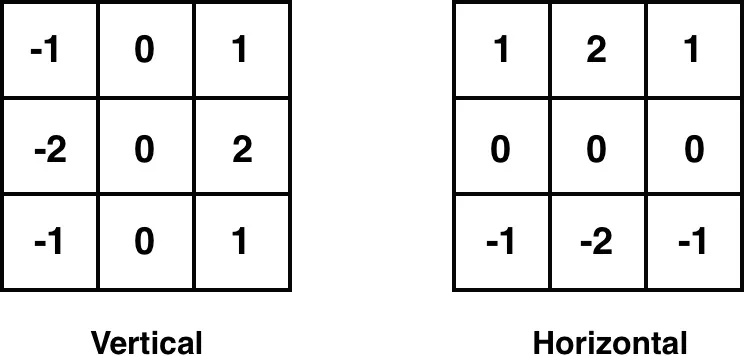

In [ ]:
class LeNet5V1(nn.Module):
    def __init__(self):
        super().__init__()
        self.feature = nn.Sequential(
            #1
            nn.Conv2d(in_channels=1, out_channels=6, kernel_size=5, stride=1, padding=2),   # 28*28->32*32-->28*28
            nn.Tanh(),
            nn.AvgPool2d(kernel_size=2, stride=2),  # 14*14
            
            #2
            nn.Conv2d(in_channels=6, out_channels=16, kernel_size=5, stride=1),  # 10*10
            nn.Tanh(),
            nn.AvgPool2d(kernel_size=2, stride=2),  # 5*5
            
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=16*5*5, out_features=120),
            nn.Tanh(),
            nn.Linear(in_features=120, out_features=84),
            nn.Tanh(),
            nn.Linear(in_features=84, out_features=10),
        )
        
    def forward(self, x):
        return self.classifier(self.feature(x))
    
    

In [ ]:
model = LeNet5V1()
print(model)


In [ ]:
# функция для расчета точности
def accuracy_fn(logps, labels):
    pred_classes = torch.argmax(torch.exp(logps), axis=1)
    val_classes = labels
    return float(torch.eq(pred_classes, val_classes).sum() / labels.shape[0])


def train_batches(model,
                  train_generator,
                  valid_generator,
                  batch_size=20, epochs=40, report_positions=20, **kwargs):

    results = {'epoch_count': [], 'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

    # прогоняем данные по нейросети
    for epoch in range(epochs):
        model.train()

        train_loss = valid_loss = 0.0;
        train_correct = valid_correct = 0.0

        for X_batch, y_batch in train_generator:

            X_batch = X_batch.to(device); y_batch = y_batch.to(device)

            y_logps = model(X_batch) #логарифмы вероятности отнесения к классам
            loss = criterion(y_logps, y_batch) #кросс-энтропия

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            train_loss += loss.data.item()
            train_correct += accuracy_fn(y_logps, y_batch) * y_batch.shape[0]

        train_loss /= len(train_generator.dataset)
        train_acc = 100 * train_correct / len(train_generator.dataset)

        # Валидацию тоже делаем по батчам
        model.eval()

        for valid_batches, (X_val_batch, y_val_batch) in enumerate(valid_generator):
            X_val_batch = X_val_batch.to(device); y_val_batch = y_val_batch.to(device)
            y_batch_logps = model(X_val_batch)
            loss = criterion(y_batch_logps, y_val_batch)

            valid_loss += loss.data.item()
            valid_correct += accuracy_fn(y_batch_logps, y_val_batch) * y_val_batch.shape[0]

        valid_loss /= len(valid_generator.dataset)
        valid_acc = 100 * valid_correct / len(valid_generator.dataset)

        results['epoch_count'] += [epoch]
        results['train_loss'] += [ train_loss ]
        results['train_acc'] += [ train_acc ]
        results['val_loss'] += [ valid_loss ]
        results['val_acc'] += [ valid_acc ]

        if epoch % (epochs // report_positions) == 0 or epochs<50:
            print(f"Epoch: {epoch+1:4.0f} | Train Loss: {train_loss:.5f}, "+\
                  f"Accuracy: {train_acc:.2f}% | \
                Validation Loss: {valid_loss:.5f}, Accuracy: {valid_acc:.2f}%")

    return results

# рисовалка графиков
def plot_results(results):

    fig, axs = plt.subplots(1,2)

    fig.set_size_inches(10,3)

    for i, loss_acc in enumerate(['loss', 'acc']):
        for train_val in ['train', 'val']:
            axs[i].plot(results['epoch_count'], results[f'{train_val}_{loss_acc}'], label=f'{loss_acc} {train_val}')

        axs[i].legend()

    plt.show()

In [ ]:
device = "cuda" if torch.cuda.is_available() else \
    "mps" if torch.backends.mps.is_built() else "cpu"
device

In [ ]:

dict_vary = {'hidden': 32,
            'activation': 'tanh',
            'batch_size': batch_size,
            'lr': 0.01,
            'momentum': 0.9,
            'optimizer': 'RMSprop',
            'epochs': 60}

model = LeNet5V1().to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=dict_vary['lr'])
criterion = nn.CrossEntropyLoss()

results = train_batches(model,
                        train_generator_MNIST,
                        val_generator_MNIST, report_positions=6, **dict_vary)

plot_results(results)
summary(model,
        input_size=images.shape,
        col_names=["input_size", "output_size", "num_params"],
        device=device
       )

## Использование сверточных нейросетей для классификации полноцветных изображений

Будет использоваться набор данных cats vs. dogs:
`https://www.kaggle.com/c/dogs-vs-cats/data`.

Он состоит из изображений среднего размера, в формате JPEG, примерно таких:

![cats_vs_dogs_samples](https://s3.amazonaws.com/book.keras.io/img/ch5/cats_vs_dogs_samples.jpg)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Копируем файлы в runtime (иначе обучение будет идти ооочень медленно).

In [ ]:
!cp -r /content/drive/MyDrive/datasets/cats_and_dogs_small /content/data

In [ ]:
!ls -al /content/data

Датасет уже разбит на обучающую, валидационную и тестовую выборки. Тестовая выборка нами использоваться не будет. Ниже создаем необходимые переменные и убеждаемся, что все файлы на местах.

In [ ]:
import os, shutil

base_dir = 'data/cats_and_dogs_small'
# base_dir = '/content/data'

train_dir = os.path.join(base_dir, 'train')
validation_dir = os.path.join(base_dir, 'validation')

train_cats_dir = os.path.join(train_dir, 'cats')
train_dogs_dir = os.path.join(train_dir, 'dogs')

validation_cats_dir = os.path.join(validation_dir, 'cats')
validation_dogs_dir = os.path.join(validation_dir, 'dogs')

print('total training cat images:', len(os.listdir(train_cats_dir)))
print('total training dog images:', len(os.listdir(train_dogs_dir)))
print('total validation cat images:', len(os.listdir(validation_cats_dir)))
print('total validation dog images:', len(os.listdir(validation_dogs_dir)))

In [ ]:
IMAGE_WIDTH=150
IMAGE_HEIGHT=150

IMAGE_SIZE=(IMAGE_WIDTH, IMAGE_HEIGHT)

# простой трансформинг:
data_transforms = transforms.Compose([
    transforms.Resize(size=IMAGE_SIZE), # делаем все картинки квадратными
    transforms.ToTensor(), # преобразуем в тензор 
])

train_data = datasets.ImageFolder(root=train_dir, # target folder of images
                                  transform=data_transforms, # transforms to perform on data (images)
                                  target_transform=None) # transforms to perform on labels (if necessary)
val_data = datasets.ImageFolder(root=validation_dir, transform=data_transforms)

print(f"Train data:\n{train_data}\nTest data:\n{val_data}")

In [ ]:
# названия классов
class_names = train_data.classes
print("Class names: ",class_names)

# ...в виде словаря
class_dict = train_data.class_to_idx
print("Class names as a dict: ",class_dict)


In [ ]:
ix_random_image = np.random.choice(len(train_data))

img, label = train_data[ix_random_image]
print(f"Image tensor:\n{img}")
print(f"Image shape: {img.shape}")
print(f"Image datatype: {img.dtype}")
print(f"Image label: {label}={class_names[label]}")
display(transforms.ToPILImage()(img))

Создаем генераторы и разделяем загрузку данных на несколько ядер нашего/наших CPU.

In [ ]:
NUM_WORKERS = os.cpu_count()
print(f'Cores: {NUM_WORKERS}')

BATCH_SIZE = 20

train_gen = DataLoader(dataset=train_data, 
                              batch_size=BATCH_SIZE,
                              num_workers=NUM_WORKERS,
                              shuffle=True) 

val_gen = DataLoader(dataset=val_data, 
                             batch_size=BATCH_SIZE, 
                             num_workers=NUM_WORKERS, 
                             shuffle=False)


In [ ]:
# визуализируем батч
images, labels = next(iter(train_gen))
images_np = images.numpy()

print(images.shape)

fig = plt.figure(figsize=(20, 4))
for idx in np.arange(20):
    ax = fig.add_subplot(2, 20//2, idx+1, xticks=[], yticks=[])
    ax.imshow(np.transpose(images_np[idx], (1,2,0)))
    ax.set_title(class_names[labels[idx].item()])

## Строим нейросеть

Делаем ее как композицию 4-х слоев ```Conv2D``` и ```MaxPooling2D```, емкость карт признаков - 32, 64, 128, 128. Перед выходом добавляем два полносвязных ```Dense``` слоя. В качестве функции активации выбираем (конечно) ```relu```, в последнем слое функцию активаци не делаем.

Такая сеть использовалась Ф. Шолле в его книге про фреймворк Keras.


In [ ]:
class ImageClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Sequential(
            nn.Conv2d(in_channels=3, # принимает трехканальное изображение 3, 150, 150
                     out_channels=32, # отдает карту признаков на 32 канала: 32, 148, 148
                     kernel_size=3, # ядро размера 3х3
                     padding=0,
                     bias=False),
            nn.ReLU(),
            nn.MaxPool2d(2)) # отдает карту признаков на 32 канала: 32, 74, 74

        # ваш код здесь
        # ваш код здесь
        self.conv2 = nn.Sequential(
            nn.Conv2d(in_channels=32, # принимает трехканальное изображение 32, 74, 74
                     out_channels=64, # отдает карту признаков на 32 канала: 32, 72, 72
                     kernel_size=3, # ядро размера 3х3
                     padding=0,
                     bias=False),
            nn.ReLU(),
            nn.MaxPool2d(2))

        self.conv3 = nn.Sequential(
            nn.Conv2d(in_channels=64, # принимает трехканальное изображение 64, 36, 36
                     out_channels=128, # отдает карту признаков на 32 канала: 128, 34, 34
                     kernel_size=3, # ядро размера 3х3
                     padding=0,
                     bias=False),
            nn.ReLU(),
            nn.MaxPool2d(2))

        self.conv4 = nn.Sequential(
            nn.Conv2d(in_channels=128, # принимает трехканальное изображение 128, 17, 17
                     out_channels=128, # отдает карту признаков на 32 канала: 128, 15, 15
                     kernel_size=3, # ядро размера 3х3
                     padding=0,
                     bias=False),
            nn.ReLU(),
            nn.MaxPool2d(2))

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=128*7*7 , out_features=512),
            nn.ReLU(),
            nn.Linear(in_features=512, out_features=2),
        )

    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x = self.conv4(x)
        x = self.classifier(x)
        return x

model = ImageClassifier().to(device)
print(model)

summary(model,
        input_size=images.shape,
        col_names=["input_size", "output_size", "num_params"],
        device=device
       )

Выбираем функцию потерь ```crossentropy```, оптимизатор - ```RMSprop```, метрика - точность (```accuracy```).

In [ ]:
criterion = nn.CrossEntropyLoss()

y_preds = model(images.to(device))
print(y_preds)
print(labels.to(device))

loss = criterion(y_preds, labels.to(device))
print("Loss", loss.data.item())

print("Acccuracy", (y_preds.argmax(dim=1) == labels.to(device)).float().mean())



In [ ]:
def train_batches(model,
                  train_generator,
                  valid_generator,
                  batch_size=20, epochs=40, report_positions=20, **kwargs):

    results = {'epoch_count': [], 'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

    # прогоняем данные по нейросети
    for epoch in range(epochs):
        model.train()

        train_loss = valid_loss = 0.0;
        train_correct = valid_correct = 0.0

        for X_batch, y_batch in train_generator:

            X_batch = X_batch.to(device); y_batch = y_batch.to(device)

            y_preds = model(X_batch) 
            loss = criterion(y_preds, y_batch) 

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            train_loss += loss.data.item()
            train_correct += (y_preds.argmax(dim=1) == y_batch).float().sum()

        train_loss /= len(train_generator.dataset)
        train_acc = 100 * train_correct / len(train_generator.dataset)    

        # Валидацию тоже делаем по батчам
        model.eval()

        for valid_batches, (X_val_batch, y_val_batch) in enumerate(valid_generator):
            X_val_batch = X_val_batch.to(device); y_val_batch = y_val_batch.to(device)
            y_batch_preds = model(X_val_batch)
            loss = criterion(y_batch_preds, y_val_batch)

            valid_loss += loss.data.item()
            valid_correct += (y_batch_preds.argmax(dim=1) == y_val_batch).float().sum()

        valid_loss /= len(valid_generator.dataset)
        valid_acc = 100 * valid_correct / len(valid_generator.dataset)

        results['epoch_count'] += [epoch]
        results['train_loss'] += [ train_loss ]
        results['train_acc'] += [ float(train_acc) ]
        results['val_loss'] += [ valid_loss ]
        results['val_acc'] += [ float(valid_acc) ]

        if epoch % (epochs // report_positions) == 0 or epochs<50:
            print(f"Epoch: {epoch+1:4.0f} | Train Loss: {train_loss:.5f}, "+\
                  f"Accuracy: {train_acc:.2f}% | \
            Validation Loss: {valid_loss:.5f}, Accuracy: {valid_acc:.2f}%")

    return results

# рисовалка графиков
def plot_results(results):

    fig, axs = plt.subplots(1,2)

    fig.set_size_inches(10,3)

    for i, loss_acc in enumerate(['loss', 'acc']):
        for train_val in ['train', 'val']:
            axs[i].plot(results['epoch_count'], results[f'{train_val}_{loss_acc}'], label=f'{loss_acc} {train_val}')

        axs[i].legend()

    plt.show()

In [ ]:
model = ImageClassifier().to(device)
optimizer = torch.optim.Adam(params=model.parameters(), lr=3e-4)

results = train_batches(model,
                        train_gen,
                        val_gen, epochs=30, )

plot_results(results)

Очевидно переобучение: показатели на обучающей выборке гораздо лучше, чем на контрольной. Что делать?